In [57]:
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import pandas as pd
import numpy as np


In [58]:
# Reading the dataset
dataset = pd.read_csv("BoomBikes.csv")

In [9]:
# Display first five rows
dataset.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [10]:
# Column names
dataset.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [11]:
# Statistical summary
dataset.describe()


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [12]:
# Dataset information
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [13]:
# Assigning string values to different seasons instead of numeric values

# 1 - Spring
dataset.loc[(dataset['season'] == 1), 'season'] = 'spring'

# 2 - Summer
dataset.loc[(dataset['season'] == 2), 'season'] = 'summer'

# 3 - Fall
dataset.loc[(dataset['season'] == 3), 'season'] = 'fall'

# 4 - Winter
dataset.loc[(dataset['season'] == 4), 'season'] = 'winter'

In [14]:
dataset['season'].astype('category').value_counts()

season
fall      188
summer    184
spring    180
winter    178
Name: count, dtype: int64

In [15]:
# 0 = 2018, 1 = 2019
dataset['yr'].astype('category').value_counts()

yr
0    365
1    365
Name: count, dtype: int64

In [16]:
# Assigning string values to different months instead of numeric values

def object_map_mnths(x):
    return x.map({
        1: 'Jan',
        2: 'Feb',
        3: 'Mar',
        4: 'Apr',
        5: 'May',
        6: 'Jun',
        7: 'Jul',
        8: 'Aug',
        9: 'Sept',
        10: 'Oct',
        11: 'Nov',
        12: 'Dec'
    })

In [17]:
dataset[['mnth']] = dataset[['mnth']].apply(object_map_mnths)

In [18]:
dataset['mnth'].astype('category').value_counts()

mnth
Aug     62
Dec     62
Jul     62
Jan     62
Oct     62
May     62
Mar     62
Apr     60
Nov     60
Jun     60
Sept    60
Feb     56
Name: count, dtype: int64

In [19]:
dataset['holiday'].astype('category').value_counts()

holiday
0    709
1     21
Name: count, dtype: int64

In [20]:
def str_map_weekday(x):
    return x.map({
        1: 'Mon',
        2: 'Tues',
        3: 'Wed',
        4: 'Thurs',
        5: 'Fri',
        6: 'Sat',
        0: 'Sun'
    })

In [21]:
dataset[['weekday']] = dataset[['weekday']].apply(str_map_weekday)

In [22]:
dataset['weekday'].astype('category').value_counts()

weekday
Mon      105
Sat      105
Sun      105
Fri      104
Thurs    104
Tues     104
Wed      103
Name: count, dtype: int64

In [23]:
dataset['workingday'].astype('category').value_counts()

workingday
1    499
0    231
Name: count, dtype: int64

In [24]:
# 1 = Clear, Few clouds, Partly Cloudy
dataset.loc[(dataset['weathersit'] == 1), 'weathersit'] = 'A'

# 2 = Mist, Cloudy
dataset.loc[(dataset['weathersit'] == 2), 'weathersit'] = 'B'

# 3 = Light Snow, Heavy Rain
dataset.loc[(dataset['weathersit'] == 3), 'weathersit'] = 'C'

In [25]:
dataset['weathersit'].astype('category').value_counts()

weathersit
A    463
B    246
C     21
Name: count, dtype: int64

In [26]:
# Importing libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

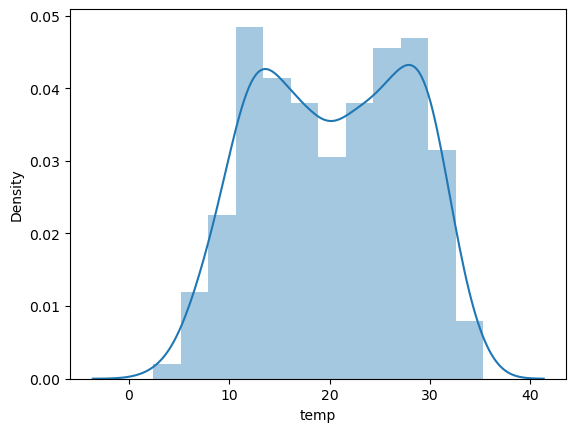

In [27]:
# Temperature
sns.distplot(dataset['temp'])
plt.show()

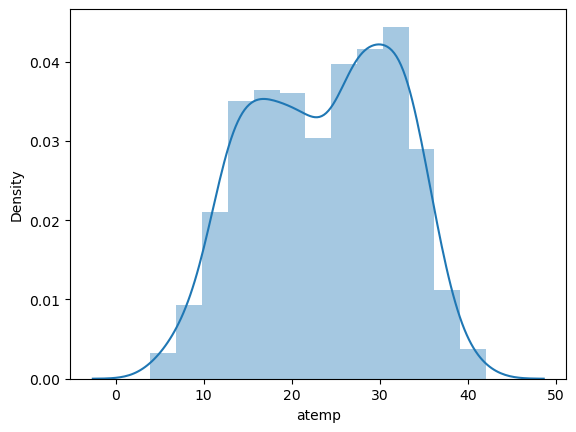

In [28]:
# Actual Temperature
sns.distplot(dataset['atemp'])
plt.show()

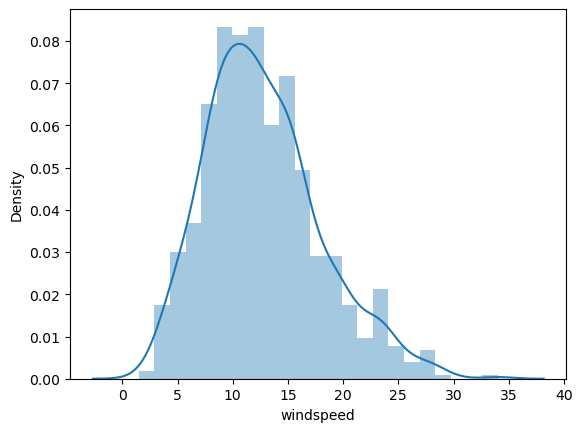

In [29]:
# Wind Speed
sns.distplot(dataset['windspeed'])
plt.show()

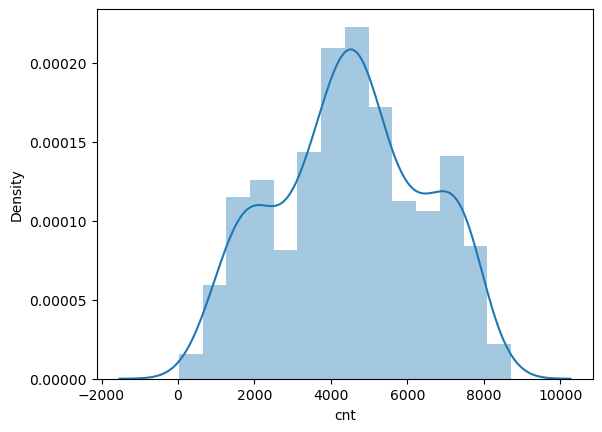

In [30]:
# Target variable: Count of total rental bikes including both casual and registered
sns.distplot(dataset['cnt'])
plt.show()

In [31]:
dataset_categorical = dataset.select_dtypes(include=['object'])

In [32]:
dataset_categorical.columns

Index(['dteday', 'season', 'mnth', 'weekday', 'weathersit'], dtype='object')

In [33]:
dataset_categorical

,dteday,season,mnth,weekday,weathersit
0,01-01-2018,spring,Jan,Sat,B
1,02-01-2018,spring,Jan,Sun,B
2,03-01-2018,spring,Jan,Mon,A
3,04-01-2018,spring,Jan,Tues,A
4,05-01-2018,spring,Jan,Wed,A
...,...,...,...,...,...
725,27-12-2019,spring,Dec,Thurs,B
726,28-12-2019,spring,Dec,Fri,B
727,29-12-2019,spring,Dec,Sat,B
728,30-12-2019,spring,Dec,Sun,A


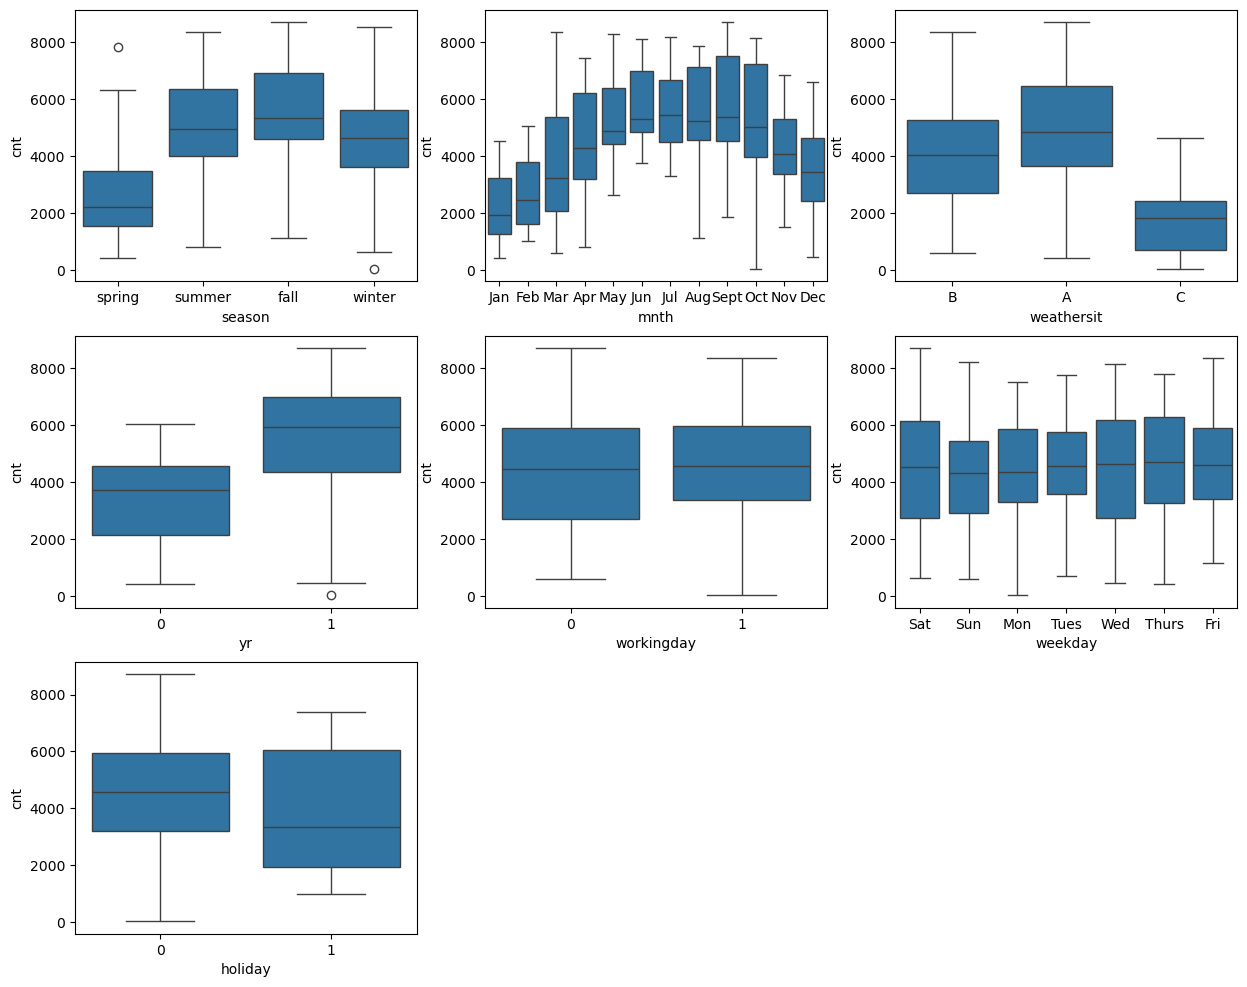

In [34]:
# Boxplots for categorical variables vs bike count (cnt)

plt.figure(figsize=(15, 12))

plt.subplot(3,3,1)
sns.boxplot(x='season', y='cnt', data=dataset)

plt.subplot(3,3,2)
sns.boxplot(x='mnth', y='cnt', data=dataset)

plt.subplot(3,3,3)
sns.boxplot(x='weathersit', y='cnt', data=dataset)

plt.subplot(3,3,4)
sns.boxplot(x='yr', y='cnt', data=dataset)

plt.subplot(3,3,5)
sns.boxplot(x='workingday', y='cnt', data=dataset)

plt.subplot(3,3,6)
sns.boxplot(x='weekday', y='cnt', data=dataset)

plt.subplot(3,3,7)
sns.boxplot(x='holiday', y='cnt', data=dataset)

plt.show()

In [35]:
# Convert selected columns to float

intVarList = ["casual", "registered", "cnt"]

for var in intVarList:
    dataset[var] = dataset[var].astype("float")

In [36]:
# Select only numeric columns

dataset_numeric = dataset.select_dtypes(include=['float64'])
dataset_numeric.head()

,temp,atemp,hum,windspeed,casual,registered,cnt
0,14.110847,18.18125,80.5833,10.749882,331.0,654.0,985.0
1,14.902598,17.68695,69.6087,16.652113,131.0,670.0,801.0
2,8.050924,9.47025,43.7273,16.636703,120.0,1229.0,1349.0
3,8.200000,10.60610,59.0435,10.739832,108.0,1454.0,1562.0
4,9.305237,11.46350,43.6957,12.522300,82.0,1518.0,1600.0


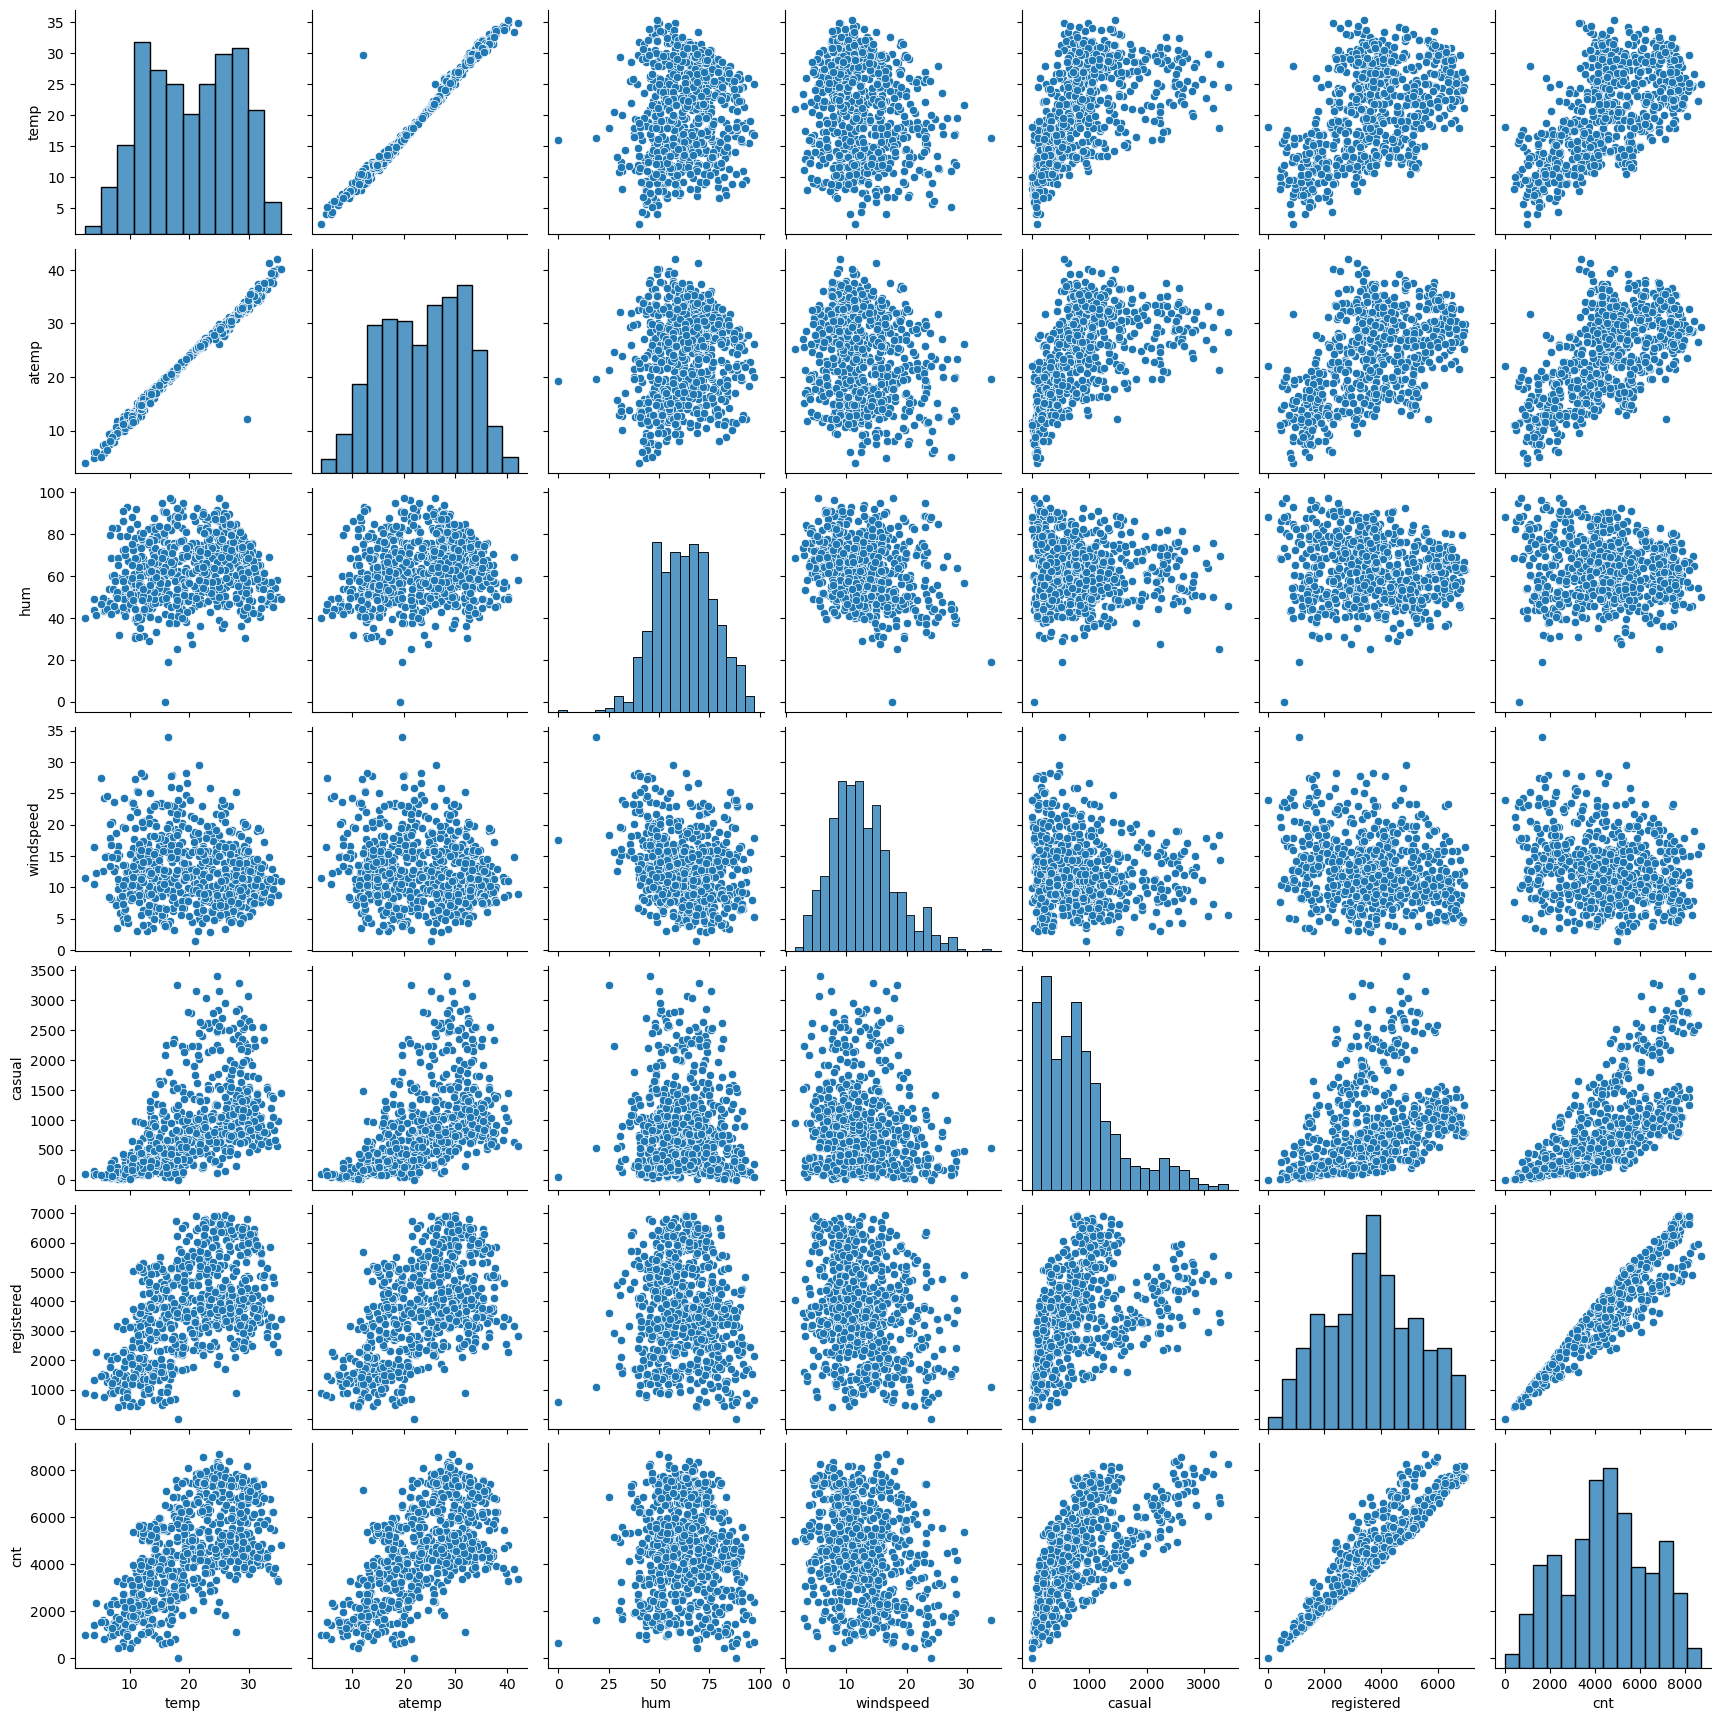

In [37]:
# Pairplot

sns.pairplot(dataset_numeric)
plt.show()

In [38]:
# Correlation matrix

cor = dataset_numeric.corr()
cor

,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.991696,0.128565,-0.158186,0.542731,0.539436,0.627044
atemp,0.991696,1.000000,0.141512,-0.183876,0.543362,0.543678,0.630685
hum,0.128565,0.141512,1.000000,-0.248506,-0.075211,-0.089212,-0.098543
windspeed,-0.158186,-0.183876,-0.248506,1.000000,-0.167995,-0.217914,-0.235132
casual,0.542731,0.543362,-0.075211,-0.167995,1.000000,0.394137,0.672123
registered,0.539436,0.543678,-0.089212,-0.217914,0.394137,1.000000,0.945411
cnt,0.627044,0.630685,-0.098543,-0.235132,0.672123,0.945411,1.000000


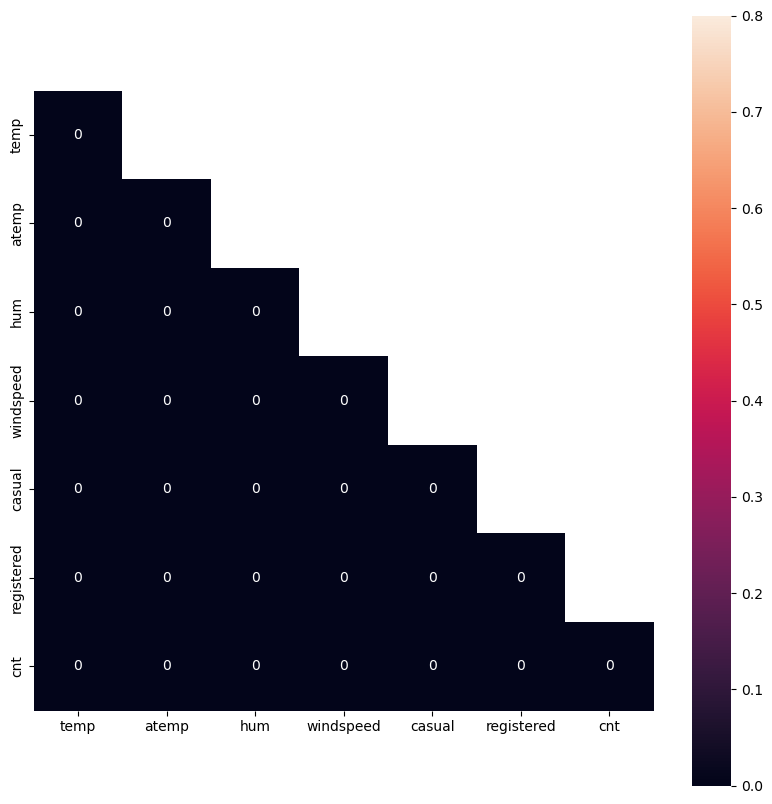

In [39]:
# Heatmap

mask = np.array(cor)
mask[np.tril_indices_from(mask)] = False

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    cor,
    mask=mask,
    vmax=0.8,
    square=True,
    annot=True
)

plt.show()

In [40]:
# Remove 'atemp' since it is highly correlated with 'temp'

dataset.drop('atemp', axis=1, inplace=True)

In [41]:
# Display the first five rows

dataset.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,spring,0,Jan,0,Sat,0,B,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,02-01-2018,spring,0,Jan,0,Sun,0,B,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,03-01-2018,spring,0,Jan,0,Mon,1,A,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,04-01-2018,spring,0,Jan,0,Tues,1,A,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,05-01-2018,spring,0,Jan,0,Wed,1,A,9.305237,43.6957,12.522300,82.0,1518.0,1600.0


In [42]:
# Data Preparation
# Select all categorical columns

dataset_categorical = dataset.select_dtypes(include=['object'])

In [43]:
# Display categorical columns

dataset_categorical.head()

,dteday,season,mnth,weekday,weathersit
0,01-01-2018,spring,Jan,Sat,B
1,02-01-2018,spring,Jan,Sun,B
2,03-01-2018,spring,Jan,Mon,A
3,04-01-2018,spring,Jan,Tues,A
4,05-01-2018,spring,Jan,Wed,A


In [44]:
# Create dummy variables for categorical columns

dataset_dummies = pd.get_dummies(
    dataset_categorical,
    drop_first=True
)

dataset_dummies.head()

,dteday_01-01-2019,dteday_01-02-2018,dteday_01-02-2019,dteday_01-03-2018,dteday_01-03-2019,dteday_01-04-2018,dteday_01-04-2019,dteday_01-05-2018,dteday_01-05-2019,dteday_01-06-2018,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [45]:
# Drop original categorical columns

dataset = dataset.drop(
    list(dataset_categorical.columns),
    axis=1
)

dataset

,instant,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
0,1,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0
...,...,...,...,...,...,...,...,...,...,...
725,726,1,0,1,10.420847,65.2917,23.458911,247.0,1867.0,2114.0
726,727,1,0,1,10.386653,59.0000,10.416557,644.0,2451.0,3095.0
727,728,1,0,0,10.386653,75.2917,8.333661,159.0,1182.0,1341.0
728,729,1,0,0,10.489153,48.3333,23.500518,364.0,1432.0,1796.0


In [46]:
# Concatenate dummy variables with the dataset

dataset = pd.concat(
    [dataset, dataset_dummies],
    axis=1
)

In [47]:
# Display first five rows

dataset.head()

,instant,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
0,1,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,985.0,...,False,False,False,True,False,False,False,False,True,False
1,2,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,801.0,...,False,False,False,False,True,False,False,False,True,False
2,3,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0,...,False,False,True,False,False,False,False,False,False,False
3,4,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0,...,False,False,False,False,False,False,True,False,False,False
4,5,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0,...,False,False,False,False,False,False,False,True,False,False


In [48]:
# Drop unnecessary columns

dataset = dataset.drop(
    ['instant', 'dteday'],
    axis=1,
    errors='ignore'
)

dataset.head()

,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt,dteday_01-01-2019,...,mnth_Oct,mnth_Sept,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thurs,weekday_Tues,weekday_Wed,weathersit_B,weathersit_C
0,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,985.0,False,...,False,False,False,True,False,False,False,False,True,False
1,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,801.0,False,...,False,False,False,False,True,False,False,False,True,False
2,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0,False,...,False,False,True,False,False,False,False,False,False,False
3,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0,False,...,False,False,False,False,False,False,True,False,False,False
4,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0,False,...,False,False,False,False,False,False,False,True,False,False


In [49]:

# Import libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
np.random.seed(100)

df_train, df_test = train_test_split(
    dataset,
    train_size=0.7,
    test_size=0.3,
    random_state=100
)

print(df_train.shape)
print(df_test.shape)

(510, 760)
(219, 760)


In [51]:
scaler = MinMaxScaler()

var = ['temp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt']

df_train[var] = scaler.fit_transform(df_train[var])

In [52]:
df_train.describe()

,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.507843,0.025490,0.676471,0.537262,0.650369,0.320768,0.254661,0.523944,0.513620
std,0.500429,0.157763,0.468282,0.225844,0.145882,0.169797,0.206011,0.228175,0.224593
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.339853,0.538643,0.199179,0.094179,0.353487,0.356420
50%,1.000000,0.000000,1.000000,0.540519,0.653714,0.296763,0.212740,0.525123,0.518638
75%,1.000000,0.000000,1.000000,0.735215,0.754830,0.414447,0.327415,0.696073,0.684710
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [53]:
import pandas as pd
import numpy as np

# Reading the dataset
dataset = pd.read_csv("BoomBikes.csv")

In [54]:
from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(100)

df_train, df_test = train_test_split(
    dataset,
    train_size=0.7,
    test_size=0.3,
    random_state=100
)

In [55]:
print(df_train.head())

     instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
653      654  16-10-2019       4   1    10        0        2           1   
576      577  31-07-2019       3   1     7        0        2           1   
426      427  03-03-2019       1   1     3        0        6           0   
728      729  30-12-2019       1   1    12        0        0           0   
482      483  28-04-2019       2   1     4        0        6           0   

     weathersit       temp    atemp      hum  windspeed  casual  registered  \
653           1  19.201653  23.0423  55.8333  12.208807     922        6612   
576           1  29.246653  33.1448  70.4167  11.083475     968        6248   
426           2  16.980847  20.6746  62.1250  10.792293     956        3110   
728           1  10.489153  11.5850  48.3333  23.500518     364        1432   
482           2  15.443347  18.8752  48.9583   8.708325    1120        3100   

      cnt  
653  7534  
576  7216  
426  4066  
728  1796  
482  422

<Figure size 3000x3000 with 0 Axes>

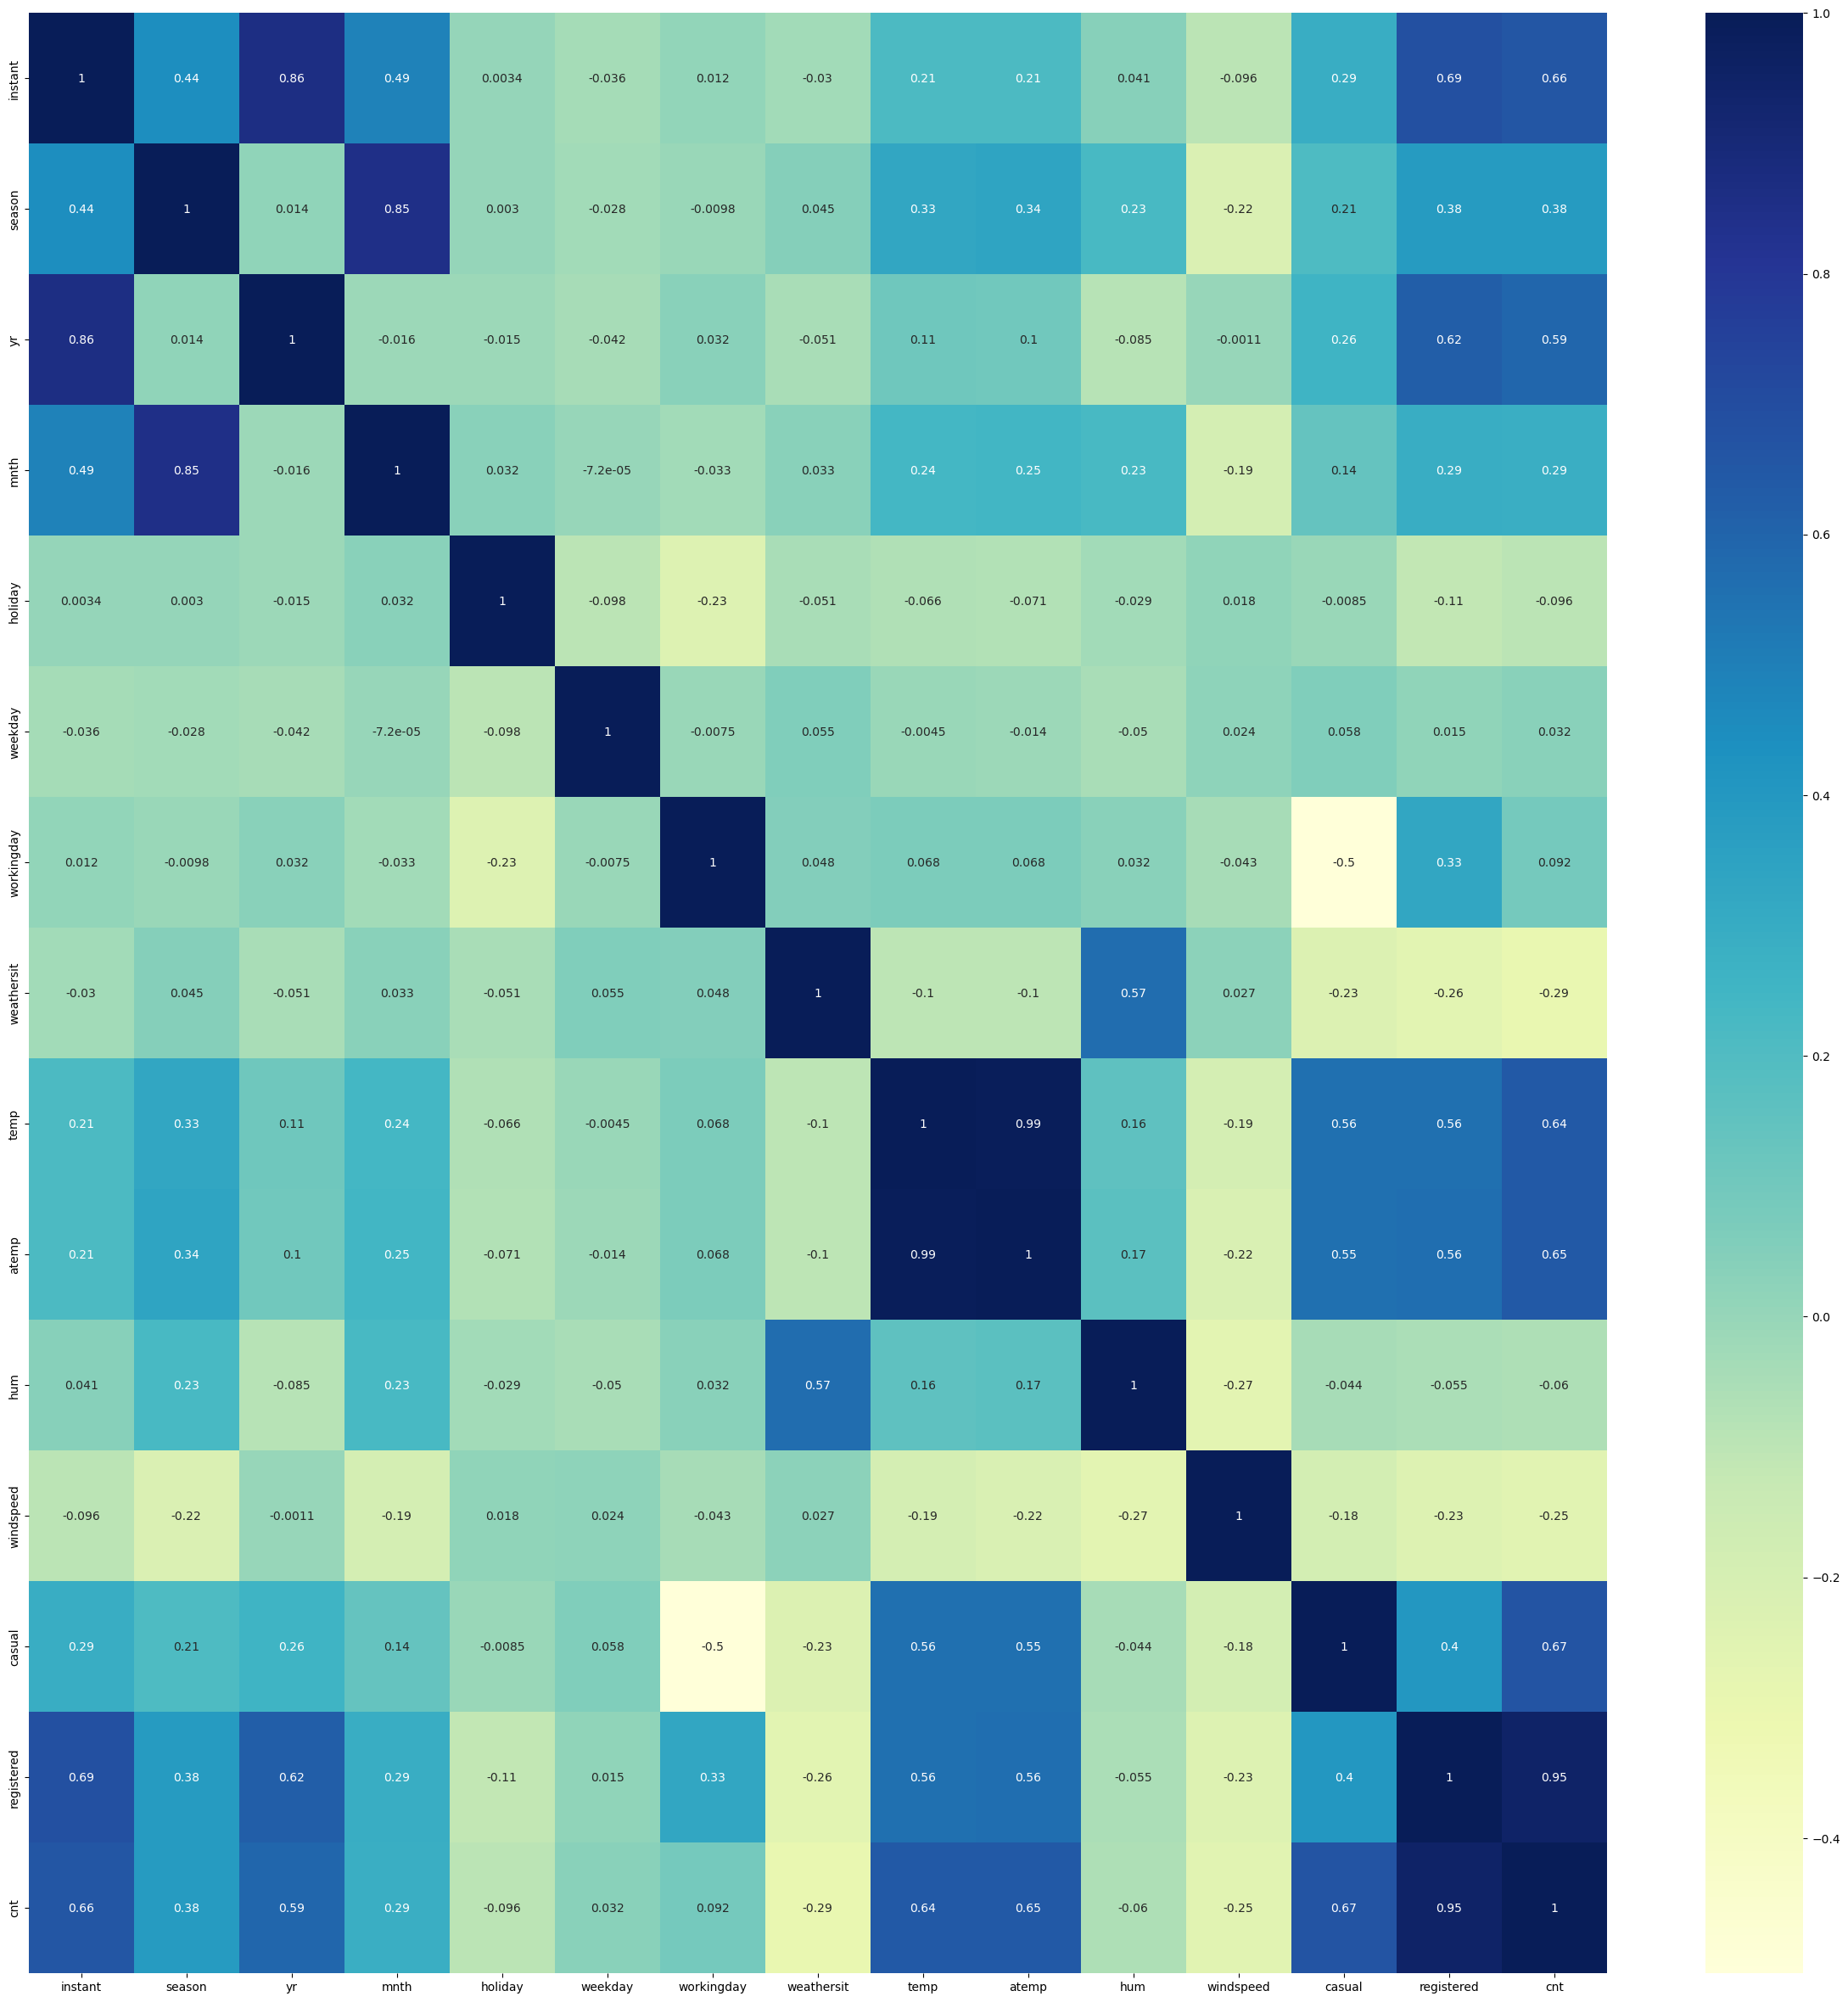

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

df_train_num = df_train.drop(columns=['dteday'])   # Replace 'dteday' with your date column name

plt.figure(figsize=(30,30))
sns.heatmap(df_train_num.corr(), annot=True, cmap='YlGnBu')
plt.show()

In [61]:
print(df_train.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [62]:
# Dividing into X and y
x_train = df_train.drop(['casual', 'registered'], axis=1)
y_train = x_train.pop('cnt')

x_train.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
653,654,16-10-2019,4,1,10,0,2,1,1,19.201653,23.0423,55.8333,12.208807
576,577,31-07-2019,3,1,7,0,2,1,1,29.246653,33.1448,70.4167,11.083475
426,427,03-03-2019,1,1,3,0,6,0,2,16.980847,20.6746,62.1250,10.792293
728,729,30-12-2019,1,1,12,0,0,0,1,10.489153,11.5850,48.3333,23.500518
482,483,28-04-2019,2,1,4,0,6,0,2,15.443347,18.8752,48.9583,8.708325


In [63]:
import numpy as np

np.array(x_train)

array([[654, '16-10-2019', 4, ..., 23.0423, 55.8333, 12.208807],
       [577, '31-07-2019', 3, ..., 33.1448, 70.4167, 11.083475],
       [427, '03-03-2019', 1, ..., 20.6746, 62.125, 10.792293],
       ...,
       [54, '23-02-2018', 1, ..., 12.28585, 42.3043, 6.305571],
       [351, '17-12-2018', 4, ..., 12.46855, 56.0833, 16.292189],
       [80, '21-03-2018', 2, ..., 20.48675, 73.7391, 19.348461]],
      dtype=object)

In [69]:
print(x_train.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')


In [70]:
print(x_train.dtypes)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
dtype: object


In [71]:
print(x_train.select_dtypes(include=['object']).columns)

Index(['dteday'], dtype='object')


In [72]:
x_train = x_train.drop(columns=['dteday'])

In [73]:
print(x_train.columns.tolist())

['instant', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


In [74]:
import statsmodels.api as sm

x_train_lm = sm.add_constant(x_train)

lr = sm.OLS(y_train, x_train_lm).fit()

lr.params

const         1569.545382
instant         -3.519532
season         421.281263
yr            3324.674612
mnth            92.590924
holiday       -595.982799
weekday         69.457700
workingday     170.427794
weathersit    -710.101746
temp            58.915423
atemp           61.378840
hum             -8.207991
windspeed      -43.696993
dtype: float64

In [75]:
print(lr.params)

const         1569.545382
instant         -3.519532
season         421.281263
yr            3324.674612
mnth            92.590924
holiday       -595.982799
weekday         69.457700
workingday     170.427794
weathersit    -710.101746
temp            58.915423
atemp           61.378840
hum             -8.207991
windspeed      -43.696993
dtype: float64


In [76]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     171.6
Date:                Fri, 31 Jul 2026   Prob (F-statistic):          5.03e-168
Time:                        22:41:59   Log-Likelihood:                -4169.6
No. Observations:                 510   AIC:                             8365.
Df Residuals:                     497   BIC:                             8420.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1569.5454    295.459      5.312      0.0

In [82]:
x_train = pd.get_dummies(
    x_train,
    columns=['season', 'mnth', 'weathersit'],
    drop_first=True
)

In [83]:
print(x_train.columns.tolist())

['instant', 'yr', 'holiday', 'weekday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weathersit_2', 'weathersit_3']


In [87]:
print(x_train_rfe2.dtypes)

const           float64
yr                int64
temp            float64
hum             float64
windspeed       float64
season_2           bool
mnth_7             bool
weathersit_3       bool
dtype: object


In [88]:
x_train_rfe2=x_train_rfe2.apply(pd.to_numeric)

In [89]:
print(x_train_rfe2.isnull().sum())

const           0
yr              0
temp            0
hum             0
windspeed       0
season_2        0
mnth_7          0
weathersit_3    0
dtype: int64


In [90]:
x_train_rfe2=x_train_rfe2.dropna()

In [91]:
import statsmodels.api as sm

x_train_rfe2 = sm.add_constant(x_train_rfe2)

In [95]:
x_train_rfe2 = x_train_rfe2.astype(float)

In [94]:
print(x_train_rfe2.dtypes)

const           float64
yr                int64
temp            float64
hum             float64
windspeed       float64
season_2           bool
mnth_7             bool
weathersit_3       bool
dtype: object


In [96]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

b = x_train_rfe2.drop('const', axis=1)

vif = pd.DataFrame()
vif['Feature'] = b.columns
vif['VIF'] = [variance_inflation_factor(b.values, i) for i in range(b.shape[1])]
vif = vif.sort_values(by='VIF', ascending=False)

print(vif)

        Feature        VIF
2           hum  10.476847
1          temp  10.219478
3     windspeed   4.740840
0            yr   2.025621
4      season_2   1.457921
5        mnth_7   1.419667
6  weathersit_3   1.085945


In [97]:
x_train_new = x_train_rfe2.drop(['hum'], axis=1)

In [98]:
import statsmodels.api as sm

lm = sm.OLS(y_train, x_train_new).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     252.0
Date:                Fri, 31 Jul 2026   Prob (F-statistic):          4.82e-148
Time:                        23:06:58   Log-Likelihood:                -4233.4
No. Observations:                 510   AIC:                             8481.
Df Residuals:                     503   BIC:                             8510.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1064.6435    187.511      5.678   

In [99]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

b = x_train_new.drop('const', axis=1)

vif = pd.DataFrame()
vif['Feature'] = b.columns
vif['VIF'] = [variance_inflation_factor(b.values, i) for i in range(b.shape[1])]
vif = vif.sort_values(by='VIF', ascending=False)

print(vif)

        Feature       VIF
1          temp  4.941170
2     windspeed  3.851774
0            yr  2.019594
3      season_2  1.447593
4        mnth_7  1.322356
5  weathersit_3  1.045011


In [100]:
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     252.0
Date:                Fri, 31 Jul 2026   Prob (F-statistic):          4.82e-148
Time:                        23:08:00   Log-Likelihood:                -4233.4
No. Observations:                 510   AIC:                             8481.
Df Residuals:                     503   BIC:                             8510.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1064.6435    187.511      5.678   

<Figure size 1000x800 with 0 Axes>

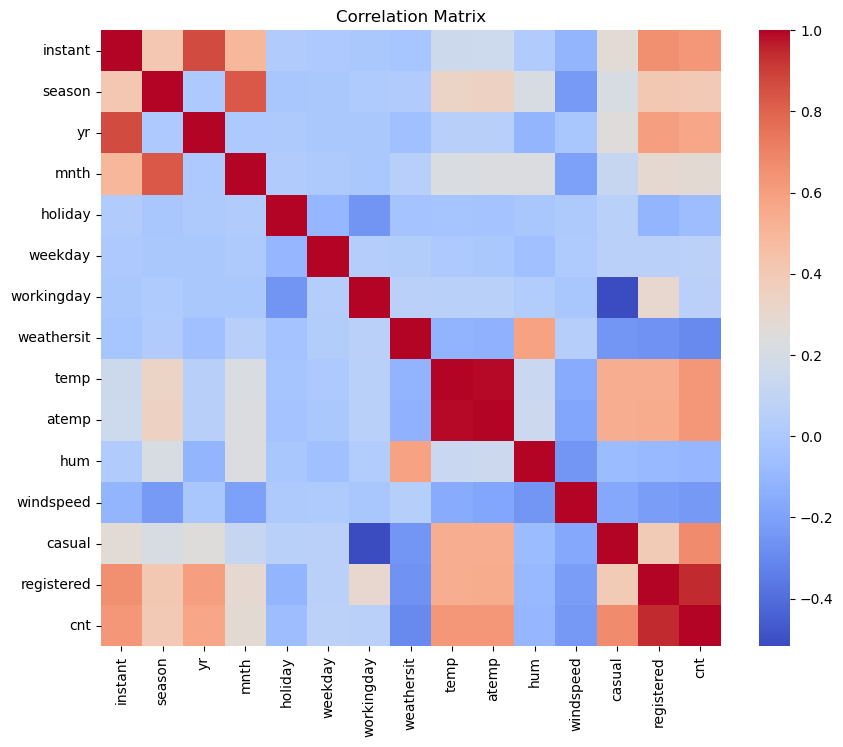

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("BoomBikes.csv")
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Correlation Matrix")
plt.show()

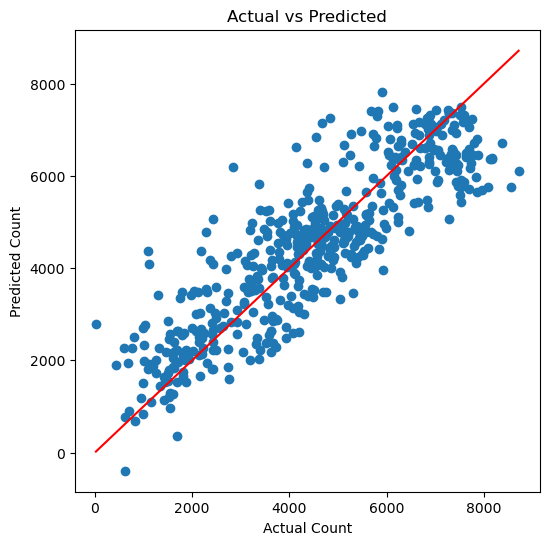

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_train, y_train_pred)
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("Actual vs Predicted")
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red')
plt.show()

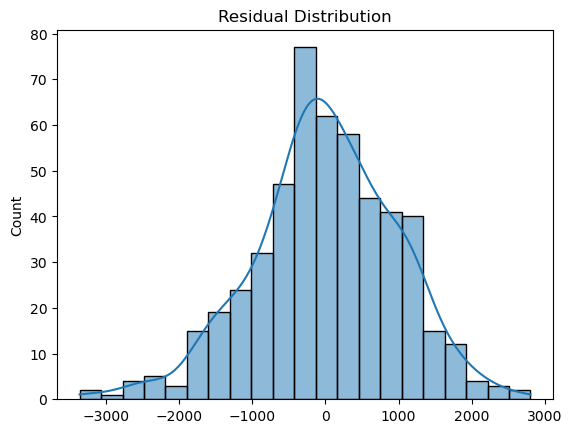

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

residuals = y_train - y_train_pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

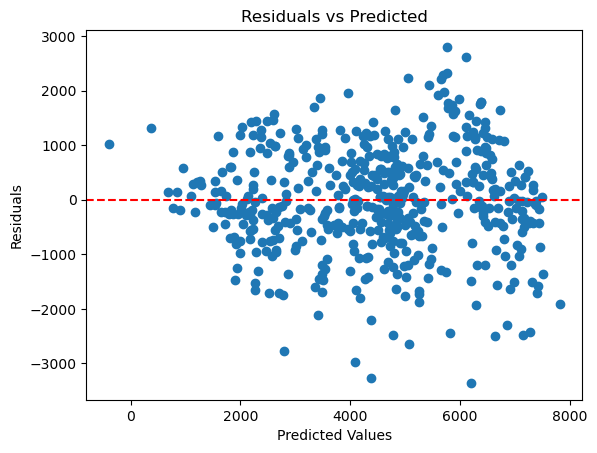

In [110]:
plt.scatter(y_train_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

In [113]:
import pandas as pd

conclusion = pd.DataFrame({
    "Parameter": [
        "Model",
        "Selected Features",
        "Maximum VIF",
        "Multicollinearity",
        "Conclusion"
    ],
    "Result": [
        "Multiple Linear Regression",
        "6",
        "4.94",
        "No Significant Multicollinearity",
        "Final model is acceptable and suitable for prediction."
    ]
})

print(conclusion)

           Parameter                                             Result
0              Model                         Multiple Linear Regression
1  Selected Features                                                  6
2        Maximum VIF                                               4.94
3  Multicollinearity                   No Significant Multicollinearity
4         Conclusion  Final model is acceptable and suitable for pre...
